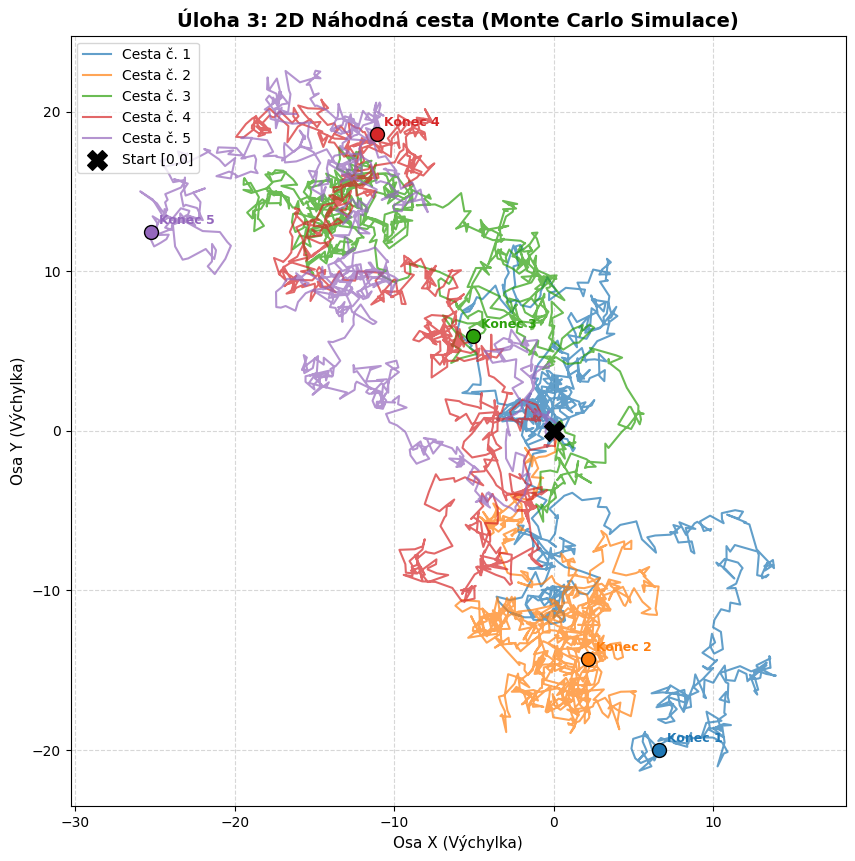

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def monte_carlo_random_walk_2d(steps, trajectories):
    """
    Generování náhodné cesty (Random Walk) ve 2D prostoru metodou Monte Carlo.
    """
    history = np.zeros((steps, trajectories, 2))

    for t in range(1, steps):
        # Náhodné kroky vygenerované z normálního rozdělení
        dx = np.random.normal(0, 0.5, size=trajectories)
        dy = np.random.normal(0, 0.5, size=trajectories)

        # Kumulativní přičítání pozice
        history[t, :, 0] = history[t-1, :, 0] + dx
        history[t, :, 1] = history[t-1, :, 1] + dy

    return history

# Parametry simulace
pocet_kroku = 800
pocet_cest = 5

# Spuštění generování dat
vysledne_cesty = monte_carlo_random_walk_2d(pocet_kroku, pocet_cest)

# --- VYKRESLENÍ GRAFU ---
plt.figure(figsize=(10, 10)) # Čtvercový formát pro nezkreslené osy

# Definice barevné palety pro jednotlivé trajektorie
paleta_barev = ["#1f77b4", "#ff7f0e", "#2ca00c", "#d62728", "#9467bd"]

for i in range(pocet_cest):
    x_coords = vysledne_cesty[:, i, 0]
    y_coords = vysledne_cesty[:, i, 1]

    # Vykreslení čáry cesty
    plt.plot(x_coords, y_coords, color=paleta_barev[i], alpha=0.7, lw=1.5, label=f"Cesta č. {i+1}")

    # Výrazné označení konce cesty
    plt.scatter(x_coords[-1], y_coords[-1], color=paleta_barev[i], edgecolors='black', s=100, zorder=4)
    plt.text(x_coords[-1] + 0.5, y_coords[-1] + 0.5, f"Konec {i+1}", fontsize=9, weight='bold', color=paleta_barev[i])

# Výrazné označení společného startu [0,0]
plt.scatter(0, 0, color='black', marker='X', s=200, zorder=5, label="Start [0,0]")

plt.title("Úloha 3: 2D Náhodná cesta (Monte Carlo Simulace)", fontsize=14, weight='bold')
plt.xlabel("Osa X (Výchylka)", fontsize=11)
plt.ylabel("Osa Y (Výchylka)", fontsize=11)

# Zajištění, aby měřítko na obou osách bylo 1:1 (kruh vypadá jako kruh, ne elipsa)
plt.axis("equal")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.show()

## Úloha 3 – Náhodná procházka (Monte Carlo)

### 1. Co tento model simuluje?
Tento model simuluje **2D náhodnou procházku** (Random Walk) pomocí metody Monte Carlo. Využívá náhodu k tomu, aby ukázal, jak se částice pohybuje v prostoru, když je v každém kroku náhodně strčena jakýmkoliv směrem. Velikost kroků se generuje z normálního (Gaussova) rozdělení.

V reálném světě to skvěle popisuje například **Brownův pohyb** (např. chaotický pohyb zrnek pylu nebo prachu ve vodě).

### 2. Jak interpretovat výsledný graf?
* **Společný start:** Všechny trajektorie začínají v jednom bodě $[0,0]$ (černý křížek). To simuluje moment, kdy částice pustíme z jednoho místa.
* **Rozbíhání drah:** Přestože mají všechny cesty úplně stejná pravidla a šance jít doleva nebo doprava je 50:50, každá z 5 simulovaných čar skončila na úplně jiném konci grafu.
* **Zubatý tvar drah:** Čáry nejsou rovné, ale divoce klikaté. Částice se často motá na jednom místě a pak najednou odskočí dál.

### 3. Hlavní závěr (Jak se to chová dlouhodobě?)
Kdybychom nasimulovali tisíce takových cest najednou, zjistili bychom, že:
1. **Průměrný střed je v nule:** Protože jsou kroky na obě strany stejně pravděpodobné, mrak částic se rozlézá rovnoměrně do všech směrů a jeho pomyslný střed je pořád v počátku.
2. **Rychlost šíření (Difuze):** Vzdálenost částice od startu neroste přímo úměrně času, ale s jeho odmocninou. To znamená, že dostat se dvakrát dál trvá systému čtyřikrát déle.

Model ukazuje, jak se dá pomocí jednoduché náhody nasimulovat složité chování z fyziky nebo chemie.